<a href="https://colab.research.google.com/github/abrahamdevargas14-byte/Data-Science-Cohort-20/blob/main/Project4_Spotify_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 4: Spotify Music Popularity Prediction
**Author:** Abe  
**Date:** May 2025  

Predict song **Popularity** (0–100) using a Decision Tree   
Goal: minimize cross-validated RMSE.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

## 2. Load Data

> **Note:** Most numeric columns load as `object` dtype because the CSV stores numbers with commas (e.g. `"1,234,567"`). We strip the commas and convert immediately — without this fix, EDA and modeling both break silently.

**Question 1:** Why do numeric columns arrive as `object` dtype when the CSV loads?

> **Answer:** pandas reads each column as text when any value contains a comma inside quotes (e.g. `"1,234,567"`). It cannot infer "number with thousands separator", so it defaults to `object` (string). The fix is to strip commas before calling `pd.to_numeric()`.

**Question 2:** What would happen if you skipped the comma-stripping step?

> **Answer:** `pd.to_numeric()` would fail to parse strings like `"1,234,567"` and return `NaN` for every affected value (`errors='coerce'`). The model would train on columns that are almost entirely NaN — after median imputation those columns collapse to a single constant, destroying their predictive power entirely.

In [2]:
url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv"
df = pd.read_csv(url)

NUMERIC_COLS = [
    'Popularity', 'Artist Followers', 'Streams',
    'Danceability', 'Energy', 'Loudness', 'Speechiness',
    'Acousticness', 'Liveness', 'Tempo', 'Duration (ms)', 'Valence'
]

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

print(f"Shape: {df.shape}")
df.head()

Shape: (1556, 23)


,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',48633449,Måneskin,3377762.0,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.800,-4.808,0.0504,0.1270,0.3590,134.002,211560.0,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),47248719,The Kid LAROI,2230022.0,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.1030,169.928,141806.0,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,40162559,Olivia Rodrigo,6266514.0,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.1540,0.3350,0.0849,166.928,178147.0,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,37799456,Ed Sheeran,83293380.0,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.3640,126.026,231041.0,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),33948454,Lil Nas X,5473565.0,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000.0,0.894,D#/Eb


In [3]:
# Confirm the conversion actually worked
print(f"Nulls per column after conversion:\n{df[NUMERIC_COLS].isnull().sum()}")
print(f"\nDtypes after conversion:\n{df[NUMERIC_COLS].dtypes}")

Nulls per column after conversion:
Popularity          11
Artist Followers    11
Streams              0
Danceability        11
Energy              11
Loudness            11
Speechiness         11
Acousticness        11
Liveness            11
Tempo               11
Duration (ms)       11
Valence             11
dtype: int64

Dtypes after conversion:
Popularity          float64
Artist Followers    float64
Streams               int64
Danceability        float64
Energy              float64
Loudness            float64
Speechiness         float64
Acousticness        float64
Liveness            float64
Tempo               float64
Duration (ms)       float64
Valence             float64
dtype: object


## 3. Target & Feature Choices

**Target → `Popularity`**  
Spotify's 0–100 score. Unlike `Streams` (a post-release running total), Popularity is available from the Spotify API for any registered track and is the right thing to predict for an unreleased song.

**Drop these columns — we wouldn't have them for a new song:**  
`Streams`, `Highest Charting Position`, `Number of Times Charted`, `Week of Highest Charting`, `Weeks Charted`, `Song ID`, `Song Name`, `Index`

**Keep (easy, pre-release features):**  
`Danceability`, `Energy`, `Loudness`, `Speechiness`, `Acousticness`, `Liveness`, `Valence`, `Tempo`, `Duration (ms)`, plus a log-transformed `Artist Followers`.

**Note on Genre & Chord:** Both are technically pre-release but require one-hot encoding and introduce many sparse columns. Excluded for this baseline — adding them is a natural next step.

## 4. Quick Data Prep

In [4]:
drop_cols = [
    'Index', 'Highest Charting Position', 'Number of Times Charted',
    'Week of Highest Charting', 'Streams', 'Weeks Charted',
    'Song ID', 'Song Name', 'Artist', 'Genre', 'Chord',
    'Release Date', 'Week of Highest Charting'
]
data = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore').copy()

# Log-transform Artist Followers to handle extreme right skew
data['log_artist_followers'] = np.log1p(data['Artist Followers'])
data.drop(columns=['Artist Followers'], inplace=True)

# Convert duration to seconds for interpretability
data['duration_sec'] = data['Duration (ms)'] / 1000
data.drop(columns=['Duration (ms)'], inplace=True)

# Quantify before imputing and deduplicating
nan_count = data.isnull().sum().sum()
data.fillna(data.median(numeric_only=True), inplace=True)
print(f"NaN values imputed with median: {nan_count}")

before_dedup = len(data)
data.drop_duplicates(inplace=True)
print(f"Duplicate rows removed: {before_dedup - len(data)}")
print(f"Final row count: {len(data)}")

TARGET = 'Popularity'
X = data.drop(columns=[TARGET])
y = data[TARGET]

print(f"\nFeatures: {list(X.columns)}")
print(f"Rows: {len(X)}  |  Target mean: {y.mean():.1f}  std: {y.std():.1f}")

NaN values imputed with median: 121
Duplicate rows removed: 35
Final row count: 1521

Features: ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Liveness', 'Tempo', 'Valence', 'log_artist_followers', 'duration_sec']
Rows: 1521  |  Target mean: 70.0  std: 15.9


**Question 3:** Why use `log1p` instead of plain `log` for Artist Followers?

> **Answer:** `log(0)` is undefined — any artist with 0 followers would break the transformation. `log1p(0) = 0`, which is safe. It also compresses the enormous spread (0 to 100M+ followers) into a range where the tree can find meaningful split points.

**Question 4:** If a feature has many missing values, what are your options besides median imputation?

> **Answer:** (1) Drop the feature if missingness is >50% and it's low-signal. (2) Use a model-based imputer (`IterativeImputer` / KNN imputer). (3) Add a binary indicator column flagging which rows were imputed, letting the model learn whether missingness itself is informative.

**Question 5:** Why is it defensible to drop `Genre` and `Chord` even though they are pre-release?

> **Answer:** Genre is inconsistently labeled and requires one-hot encoding, adding many sparse columns. Chord has many unique values and unclear predictive signal. A follow-up model could add them with proper encoding and compare CV RMSE.

## 5. EDA

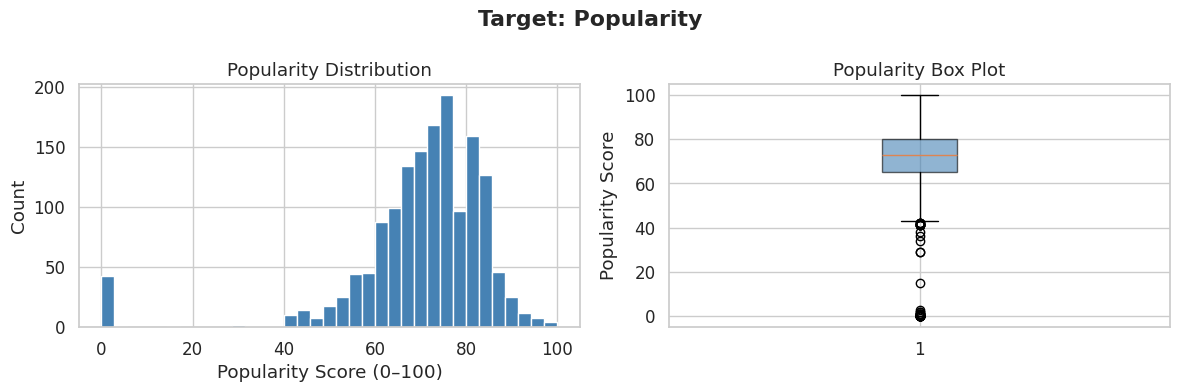

count    1521.000000
mean       69.982249
std        15.870830
min         0.000000
25%        65.000000
50%        73.000000
75%        80.000000
max       100.000000
Name: Popularity, dtype: float64


In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=35, color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution')
axes[0].set_xlabel('Popularity Score (0–100)')
axes[0].set_ylabel('Count')

axes[1].boxplot(y, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Popularity Box Plot')
axes[1].set_ylabel('Popularity Score')

plt.suptitle('Target: Popularity', fontweight='bold')
plt.tight_layout()
plt.show()
print(y.describe())

**Question 6:** What does the shape of the Popularity distribution tell you about the dataset?

> **Answer:** The distribution is left-skewed with a spike near 0 (songs with essentially no Spotify traction). Most songs cluster in the 40–80 range. This means the model will have more training examples for mid-range scores and may struggle to predict very low or very high popularity accurately.

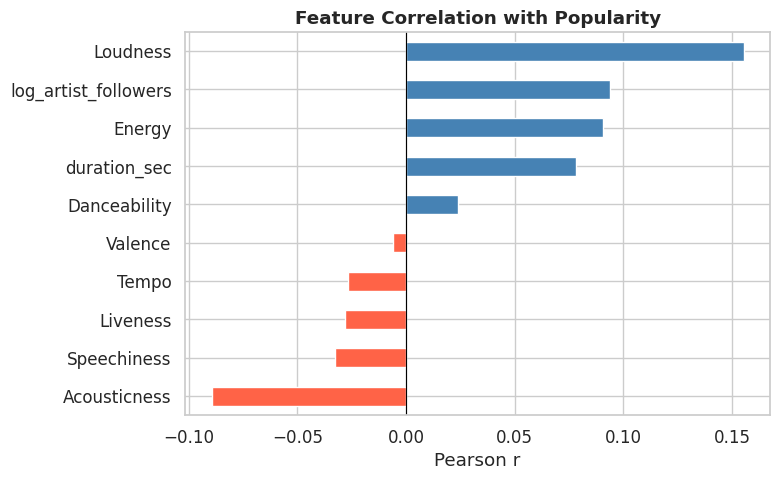

In [6]:
# Correlation with Popularity
corr = data.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', ax=ax, color=['tomato' if v < 0 else 'steelblue' for v in corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Popularity', fontweight='bold')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

> **Important:** Pearson r only measures *linear* relationships. A feature with r ≈ 0 here can still be a strong predictor for a Decision Tree if the relationship is non-linear or threshold-based. Do **not** use this chart alone to drop features before modeling — the feature importance chart in §7 gives the tree's actual opinion.

**Question 7:** If `Danceability` has near-zero Pearson r with Popularity, can you safely drop it before modeling?

> **Answer:** No — not based on Pearson r alone. Decision trees split on thresholds, not slopes, so a U-shaped or step-function relationship would show r ≈ 0 but still be exploitable by the tree. Always let the model's feature importance inform feature selection.

## 6. Decision Tree — Baseline + Depth Tuning

We use 5-fold cross-validated RMSE as our metric throughout.

`KFold` with `cross_val_score` guarantees every observation is used for both training and validation exactly once — this is more statistically rigorous than a repeated random split because it eliminates fold overlap and gives a lower-variance RMSE estimate.

In [7]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(model):
    scores = cross_val_score(model, X, y, cv=kf,
                             scoring='neg_root_mean_squared_error')
    return -scores.mean(), scores.std()

# Baseline: unpruned tree (will severely overfit)
dt_base = DecisionTreeRegressor(random_state=42)
m_base, s_base = cv_rmse(dt_base)
dt_base.fit(X, y)
print(f"Baseline DT (no depth limit)  ->  CV RMSE: {m_base:.3f} +/- {s_base:.3f}")
print(f"  Depth: {dt_base.get_depth()},  Leaves: {dt_base.get_n_leaves()}")

Baseline DT (no depth limit)  ->  CV RMSE: 14.478 +/- 0.650
  Depth: 32,  Leaves: 1254


In [8]:
# Sweep max_depth 2-20 to find optimal
depth_results = []
for d in range(2, 21):
    m, s = cv_rmse(DecisionTreeRegressor(max_depth=d, random_state=42))
    depth_results.append({'depth': d, 'mean': m, 'std': s})

depth_df = pd.DataFrame(depth_results)
best_depth = int(depth_df.loc[depth_df['mean'].idxmin(), 'depth'])
best_rmse  = depth_df['mean'].min()

# Print top depths so conclusions table has real numbers
print("Top 5 depths by CV RMSE:")
print(depth_df.sort_values('mean').head(5).to_string(index=False))
print(f"\nBaseline (no limit): {m_base:.3f}  ->  Tuned (depth={best_depth}): {best_rmse:.3f}")
print(f"Improvement: {m_base - best_rmse:.3f} RMSE points")

Top 5 depths by CV RMSE:
 depth      mean      std
     2 10.857382 0.972389
     3 10.963951 1.074435
     4 11.271313 1.160159
     6 11.675737 1.129941
     5 11.778103 1.345019

Baseline (no limit): 14.478  ->  Tuned (depth=2): 10.857
Improvement: 3.621 RMSE points


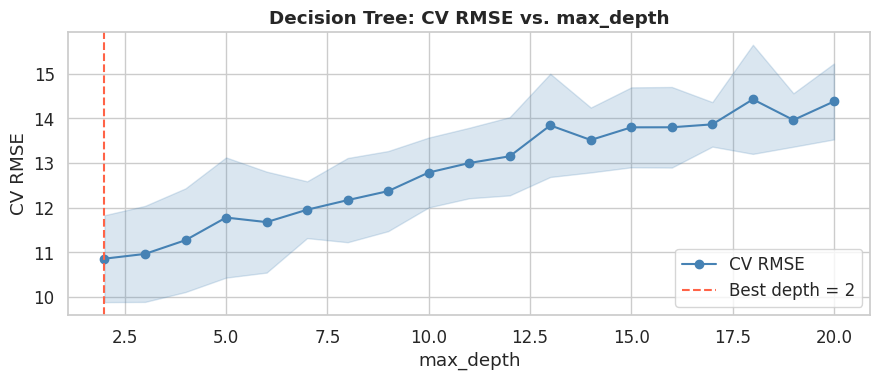

In [9]:
# Plot of Decision Tree: CV RMSE vs. max_depth
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(depth_df['depth'], depth_df['mean'], 'o-', color='steelblue', label='CV RMSE')
ax.fill_between(depth_df['depth'],
                depth_df['mean'] - depth_df['std'],
                depth_df['mean'] + depth_df['std'],
                alpha=0.2, color='steelblue')
ax.axvline(best_depth, color='tomato', linestyle='--', label=f'Best depth = {best_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('CV RMSE')
ax.set_title('Decision Tree: CV RMSE vs. max_depth', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# Tuned model
dt_tuned = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
m_tuned, s_tuned = cv_rmse(dt_tuned)
print(f"Tuned DT (max_depth={best_depth})  ->  CV RMSE: {m_tuned:.3f} +/- {s_tuned:.3f}")

Tuned DT (max_depth=2)  ->  CV RMSE: 10.857 +/- 0.972


**Question 8:** Why does CV RMSE decrease then increase as `max_depth` grows?

> **Answer:** At very shallow depths (1–2) the tree is **underfit** — too few splits to capture real patterns (high bias, low variance). As depth increases it learns more signal and RMSE falls. Past the optimal depth, the tree starts memorizing noise in individual training rows (low bias, high variance), which hurts generalization and raises CV RMSE.

**Question 9:** What is the difference between `KFold + cross_val_score` (this approach) and the lecture's 500-loop random split?

> **Answer:** Both estimate out-of-sample RMSE, but KFold is more efficient: every row is used exactly once as a validation point. The 500-loop method uses random splits that can overlap (the same row might appear in the test set many times or never), making the variance estimate noisier. KFold with `shuffle=True` and a fixed `random_state` is also fully reproducible.

## 7. Results

In [11]:
# Trained fit model
dt_tuned.fit(X, y)
y_pred_train = dt_tuned.predict(X)

train_rmse = np.sqrt(mean_squared_error(y, y_pred_train))
cv_mean, cv_std = cv_rmse(dt_tuned)

# Add R² alongside RMSE
train_r2 = r2_score(y, y_pred_train)
cv_r2    = cross_val_score(dt_tuned, X, y, cv=kf, scoring='r2').mean()

print(f"Train RMSE : {train_rmse:.3f}")
print(f"CV RMSE    : {cv_mean:.3f} +/- {cv_std:.3f}")
print(f"Gap        : {cv_mean - train_rmse:.3f}  (lower = less overfit)")
print(f"\nTrain R²  : {train_r2:.3f}")
print(f"CV R²      : {cv_r2:.3f}  (fraction of Popularity variance explained)")

# Interpret the gap explicitly
gap = cv_mean - train_rmse
if gap < 2:
    verdict = "Well-generalized — train and CV RMSE are close."
elif gap < 5:
    verdict = "Mild overfitting — model memorizes some training patterns."
else:
    verdict = "Significant overfitting — consider pruning further or adding min_samples_leaf."
print(f"Verdict    : {verdict}")

Train RMSE : 10.558
CV RMSE    : 10.857 +/- 0.972
Gap        : 0.299  (lower = less overfit)

Train R²  : 0.557
CV R²      : 0.521  (fraction of Popularity variance explained)
Verdict    : Well-generalized — train and CV RMSE are close.


**Question 10:** If train RMSE is much lower than CV RMSE, what does that mean?

> **Answer:** The model has memorized noise in the training set (overfit). It reproduces training labels well but fails on unseen songs. Reducing `max_depth` or increasing `min_samples_leaf` forces the tree to generalize rather than memorize.

**Question 11:** What hyperparameters besides `max_depth` reduce overfitting in a Decision Tree?

> **Answer:** `min_samples_split` (min rows to split a node), `min_samples_leaf` (min rows in each leaf), `max_features` (subset of features considered at each split), and `max_leaf_nodes` (hard cap on total leaves).

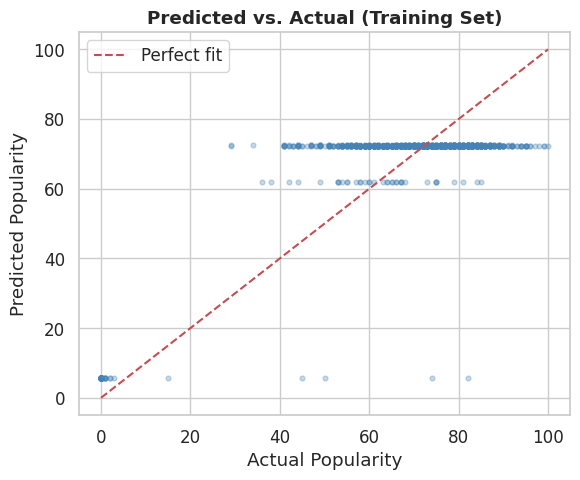

In [12]:
# Predicted vs Actual
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y, y_pred_train, alpha=0.3, s=12, color='steelblue')
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1.5, label='Perfect fit')
ax.set_xlabel('Actual Popularity')
ax.set_ylabel('Predicted Popularity')
ax.set_title('Predicted vs. Actual (Training Set)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Question 12:** In this scatter plot, where does the model struggle most?

> **Answer:** Points farthest from the diagonal have the largest errors. Decision Trees predict the mean of each leaf, so they tend to underpredict very high popularity and overpredict very low popularity. The horizontal "banding" pattern is characteristic of trees — each band is one leaf's constant prediction value.

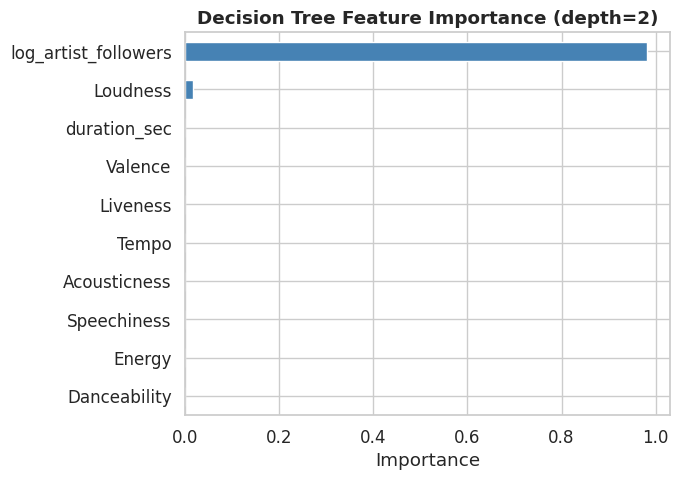

Cumulative feature importance (%):
log_artist_followers     98.2
Loudness                100.0
Energy                  100.0
Danceability            100.0
Speechiness             100.0
Acousticness            100.0
Liveness                100.0
Tempo                   100.0
duration_sec            100.0
Valence                 100.0


In [13]:
# Feature importance
imp = pd.Series(dt_tuned.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
imp.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Decision Tree Feature Importance (depth={best_depth})', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

# Print cumulative importance so dominance is quantified
imp_sorted = imp.sort_values(ascending=False)
print("Cumulative feature importance (%):")
print((imp_sorted.cumsum() * 100).round(1).to_string())

**Why does `log_artist_followers` dominate?**

Decision trees are greedy — at every node they choose the single best feature. When one feature is far stronger than the rest, it gets chosen at the root **and** at many downstream nodes. This mathematically starves every other feature of importance score, even if those features would be useful in a model without follower data.

This does **not** mean audio features are useless — it means artist fame is a stronger signal for Spotify's Popularity score than how the song sounds. A model trained without `log_artist_followers` would rely much more on audio features.

**Question 13:** What would feature importances look like without `log_artist_followers`?

> **Answer:** Re-run on `X.drop(columns=['log_artist_followers'])` and compare. Audio features would spread importance more evenly, giving a clearer picture of which sonic qualities actually matter.

**Question 14:** Why does the tree visualization below use depth=3 even when the tuned depth is higher?

> **Answer:** A full-depth tree would have hundreds of nodes — completely unreadable. Depth=3 shows the first three decision levels (highest information gain) and tells the interpretable story of what the model learned.

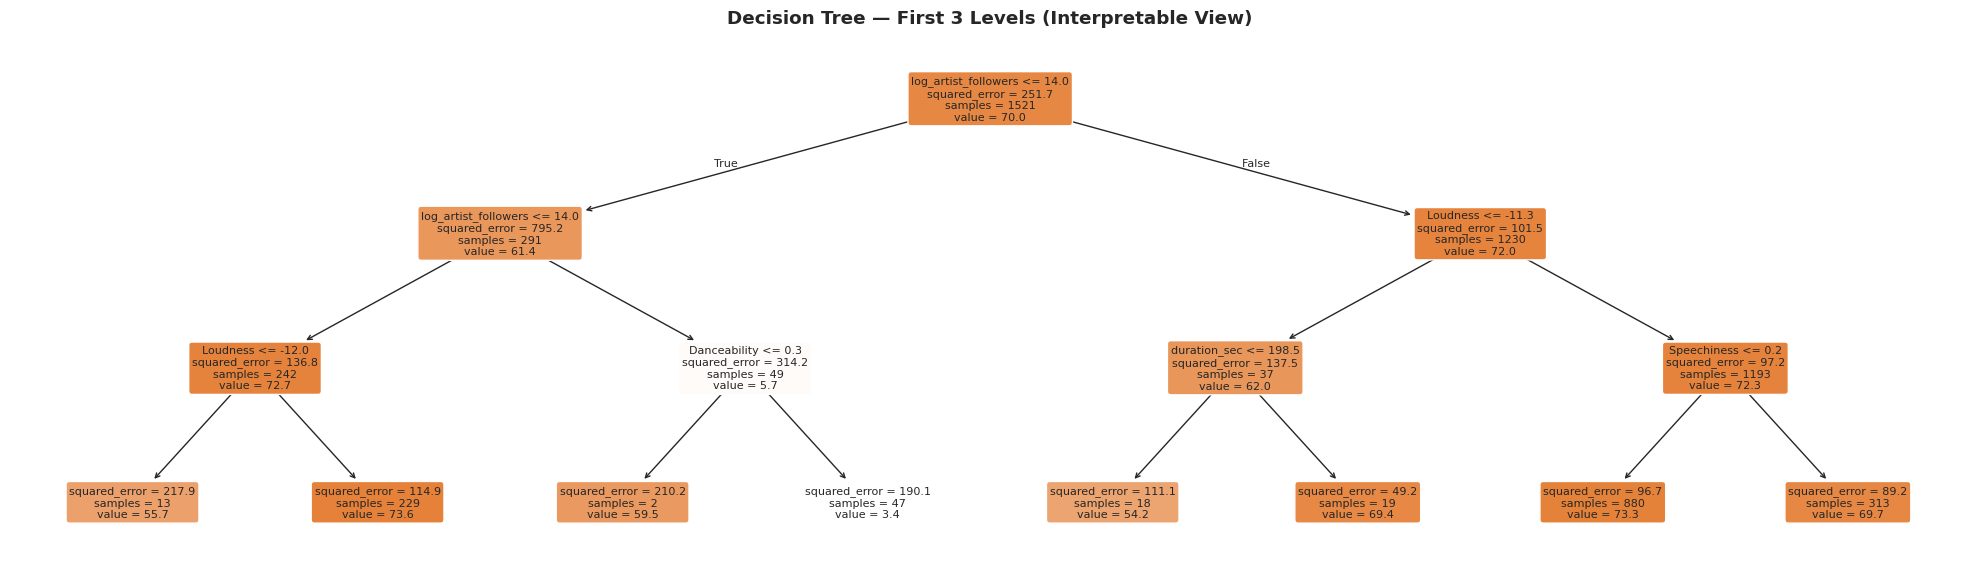

In [14]:
# Tree visualization — depth=3 slice for readability
dt_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_viz.fit(X, y)

fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(dt_viz, feature_names=X.columns.tolist(),
          filled=True, rounded=True, fontsize=8, ax=ax, precision=1)
ax.set_title('Decision Tree — First 3 Levels (Interpretable View)', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Conclusions

In [15]:
# Results summary
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

lines = [
    f"  Baseline DT (no depth limit)   CV RMSE: {m_base:.3f}  (depth {dt_base.get_depth()}, {dt_base.get_n_leaves()} leaves — severely overfit)",
    f"  Tuned DT (max_depth={best_depth})          CV RMSE: {m_tuned:.3f}  (best from depth sweep)",
    f"  Improvement                    {m_base - m_tuned:.3f} RMSE points",
    "",
    f"  CV R\u00b2 = {cv_r2:.3f} — model explains {cv_r2*100:.1f}% of Popularity variance.",
    f"  Remaining {(1-cv_r2)*100:.1f}% driven by unobservable factors (see Limitations).",
    "",
    "  Overfitting check:",
    f"    Train RMSE = {train_rmse:.3f}",
    f"    CV RMSE    = {cv_mean:.3f}",
    f"    Gap        = {cv_mean - train_rmse:.3f}",
    f"    Verdict    = {verdict}",
]
print("\n".join(lines))

RESULTS SUMMARY
  Baseline DT (no depth limit)   CV RMSE: 14.478  (depth 32, 1254 leaves — severely overfit)
  Tuned DT (max_depth=2)          CV RMSE: 10.857  (best from depth sweep)
  Improvement                    3.621 RMSE points

  CV R² = 0.521 — model explains 52.1% of Popularity variance.
  Remaining 47.9% driven by unobservable factors (see Limitations).

  Overfitting check:
    Train RMSE = 10.558
    CV RMSE    = 10.857
    Gap        = 0.299
    Verdict    = Well-generalized — train and CV RMSE are close.




 **Target:** `Popularity` — Spotify's 0–100 score, available pre-release via the API. `Streams` was excluded because it only exists after a song is released.

**Features kept:** audio features (Danceability, Energy, Loudness, etc.) + `log_artist_followers` + `duration_sec`. All post-release and ID columns dropped.

**Model:** Decision Tree Regressor, `max_depth` tuned via 5-fold CV sweep.

**Key finding:** `log_artist_followers` is the dominant predictor — *who* made the song matters more than *how* it sounds for Spotify's Popularity score. Audio features (primarily Loudness) provide secondary signal. This means a label signing an unknown artist cannot rely on audio features alone to predict chart performance.

**Limitations:**
- Viral moments, playlist placements, and marketing are unobservable — there is an inherent noise floor on RMSE that no model can cross without that data.
- CV R² leaves a large fraction of variance unexplained. Adding release timing, genre, playlist adds, and label size would be the highest-value next steps.
- Median imputation and dropping Genre/Chord are simplifications a production model would handle more carefully.

**Next steps:**
1. Re-run without `log_artist_followers` to see audio-only feature importance.
2. Add `Genre` via one-hot encoding and compare CV RMSE.
3. Try Random Forest or Gradient Boosting — ensemble methods typically outperform a single Decision Tree.

---

**Question 15:** If you were to improve this model, what single change would have the biggest impact?

> **Answer:** Adding features that capture demand signals — playlist adds, label size, release timing — would likely move the needle more than algorithm choice, because the noise floor is primarily an information problem, not a model complexity problem.

**Question 16:** What data would you need to build a genuinely good pre-release popularity predictor?

> **Answer:** Artist streaming history and trajectory, label and management team, planned playlist pitches, marketing budget, similar-song Popularity at release, seasonal release patterns, and social media momentum pre-release.